In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#### Loading the dataset

In [2]:
columns = ['age', 'work-area', 'unique-id', 'qualification', 'qualification-num', 'marital-status', 'occupation', 'relationship', 
           'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'country', 'income']

classification_df = pd.read_csv("classification_2.csv", header=None, names=columns)
classification_df.head()

,age,work-area,unique-id,qualification,qualification-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
classification_df.shape

(32561, 15)

#### Analyzing the dataset

In [4]:
classification_df.describe()

,age,unique-id,qualification-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


#### Treating null values

In [5]:
(classification_df['work-area'] == ' ?').sum()

1836

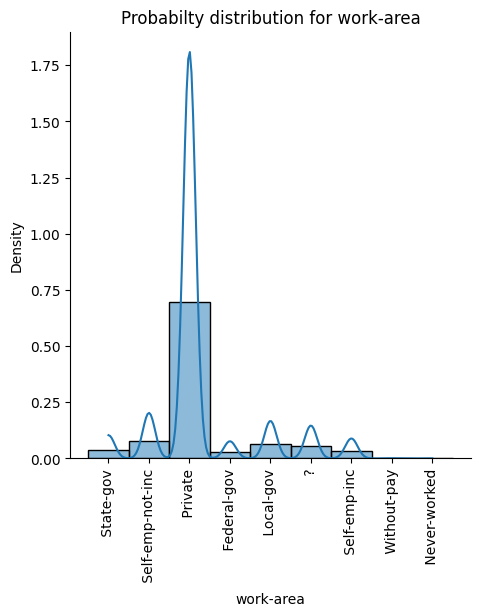

In [6]:
sns.displot(classification_df['work-area'], kde = True, stat='density')
plt.title("Probabilty distribution for work-area")
plt.xticks(rotation=90)
plt.show()

In [7]:
classification_df.replace(' ?', classification_df['work-area'].mode()[0], inplace=True)

In [9]:
(classification_df['work-area'] == ' ?').sum()

0

In [10]:
col_list=list(classification_df.columns)

#### Checking the outliers

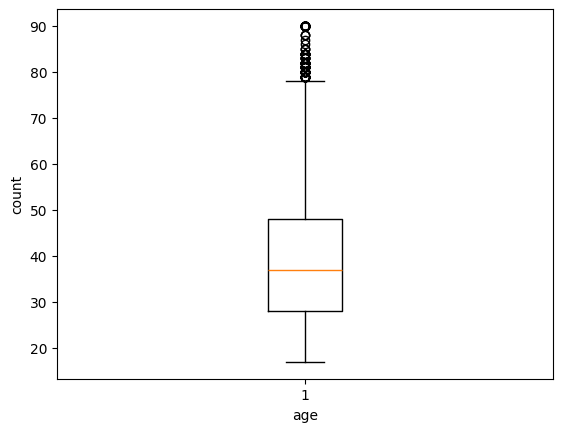

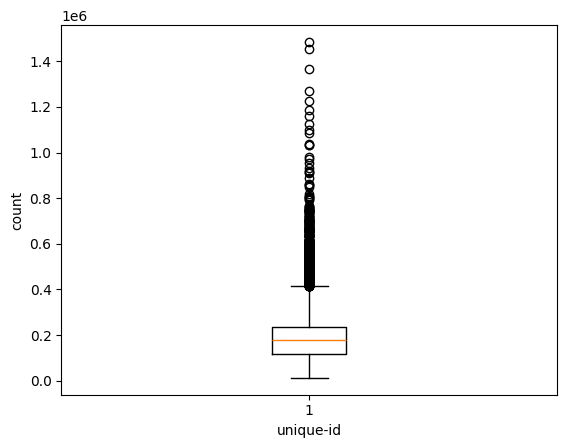

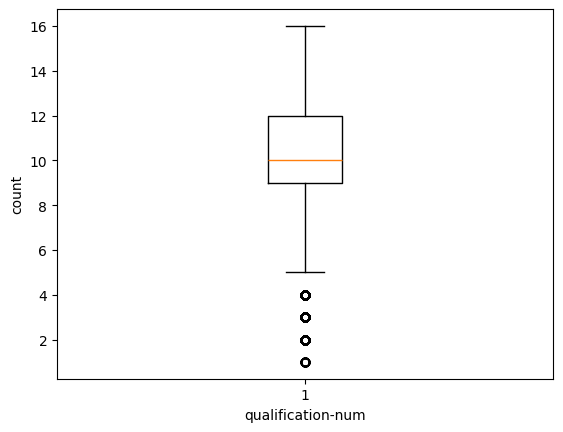

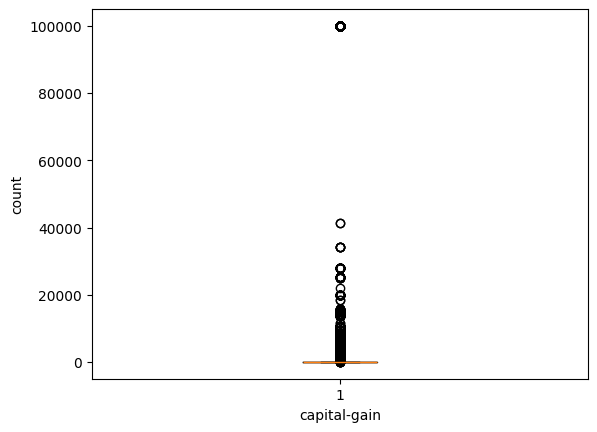

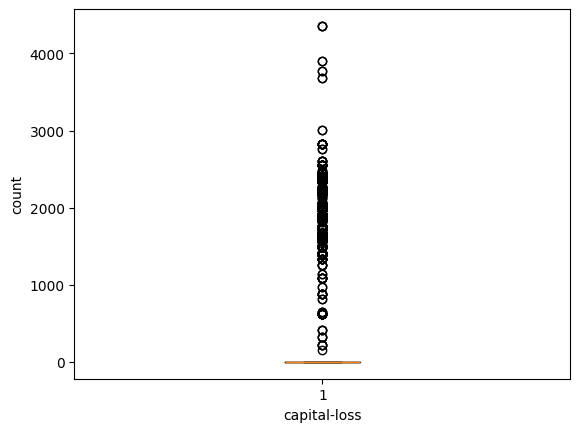

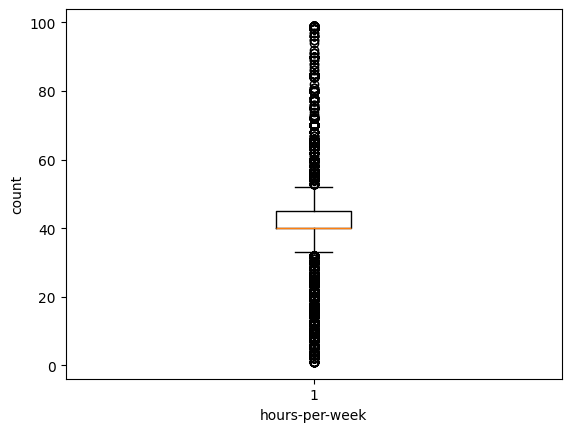

In [11]:
for i in col_list:
    if classification_df[i].dtypes==object:
        pass
    else:
        plt.boxplot(classification_df[i])
        plt.xlabel(i)
        plt.ylabel('count')
        plt.show()

#### Treating the outliers

In [12]:
numeric_cols = classification_df.select_dtypes(include=['number'])

q1 = numeric_cols.quantile(0.25)
q3 = numeric_cols.quantile(0.75)
iqr = q3 - q1

print(iqr)

age                      20.0
unique-id            119224.0
qualification-num         3.0
capital-gain              0.0
capital-loss              0.0
hours-per-week            5.0
dtype: float64


In [13]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (numeric_cols < lower_bound) | (numeric_cols > upper_bound)

# Filter the DataFrame to remove rows with any outliers
bank_df = classification_df[~outlier_mask.any(axis=1)]

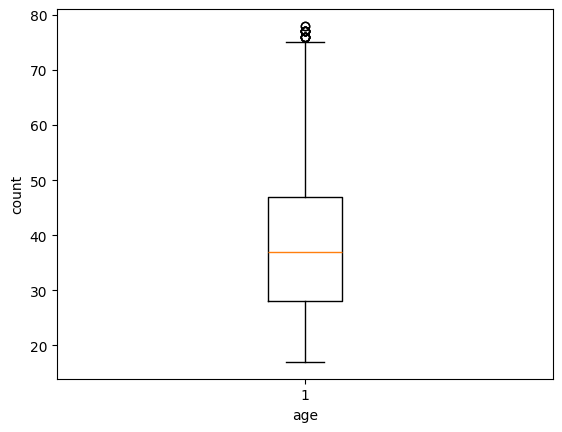

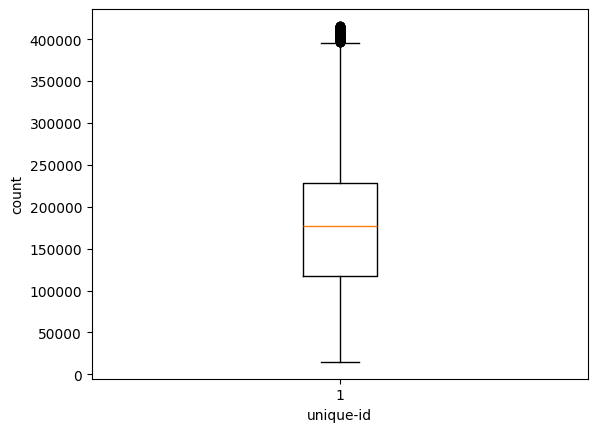

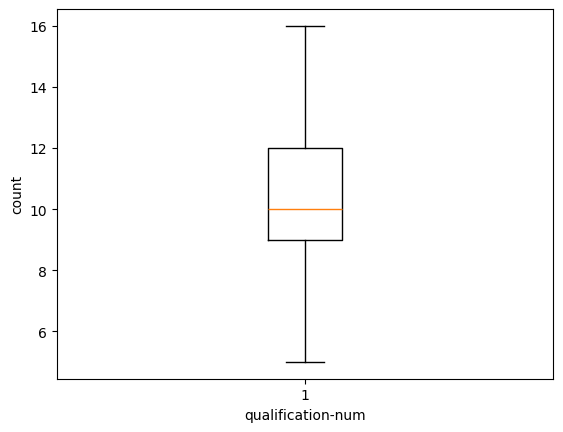

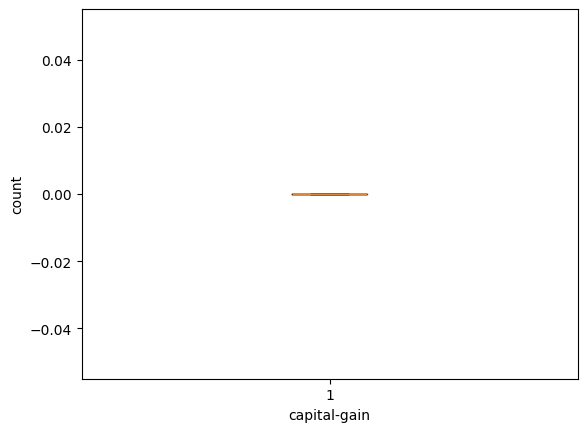

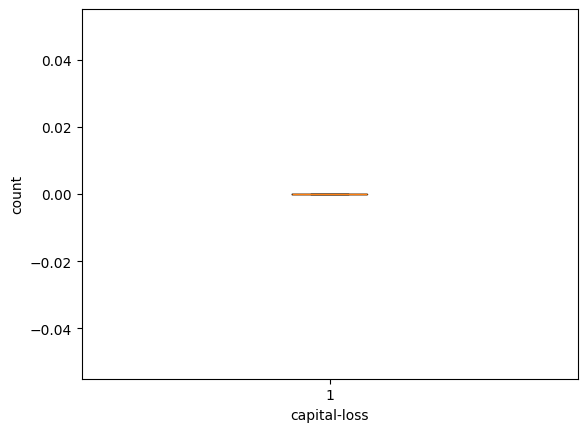

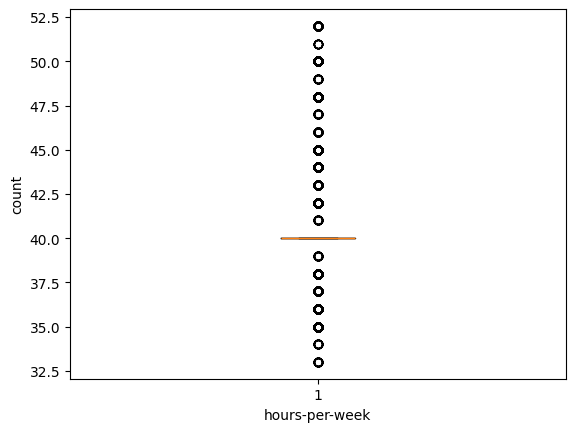

In [14]:
for i in col_list:
    if classification_df[i].dtypes==object:
        pass
    else:
        plt.boxplot(bank_df[i])
        plt.xlabel(i)
        plt.ylabel('count')
        plt.show()

In [15]:
col_list=bank_df.columns

In [16]:
col_list

Index(['age', 'work-area', 'unique-id', 'qualification', 'qualification-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'country', 'income'],
      dtype='object')

#### Label encoding

In [17]:
labelencoder=LabelEncoder()

In [18]:
for i in col_list:
    classification_df[i]=labelencoder.fit_transform(classification_df[i])

In [19]:
classification_df

,age,work-area,unique-id,qualification,qualification-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,country,income
0,22,6,2671,9,12,4,0,1,4,1,25,0,39,39,0
1,33,5,2926,9,12,2,3,0,4,1,0,0,12,39,0
2,21,3,14086,11,8,0,5,1,4,1,0,0,39,39,0
3,36,3,15336,1,6,2,5,0,2,1,0,0,39,39,0
4,11,3,19355,9,12,2,10,5,2,0,0,0,39,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,10,3,16528,7,11,2,13,5,4,0,0,0,37,39,0
32557,23,3,8080,11,8,2,6,0,4,1,0,0,39,39,1
32558,41,3,7883,11,8,6,0,4,4,0,0,0,39,39,0
32559,5,3,12881,11,8,4,0,3,4,1,0,0,19,39,0


#### Plotting correlation heatmap

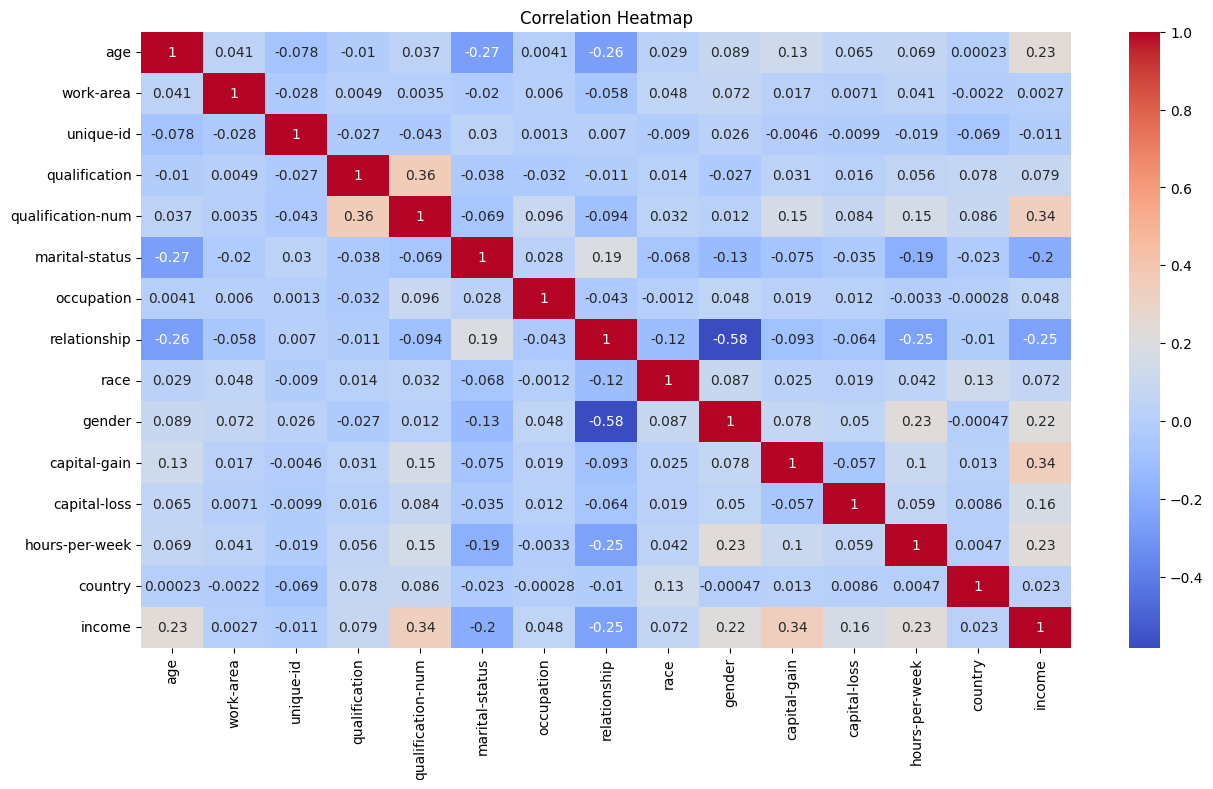

In [20]:
numeric_cols = classification_df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_cols.corr()

# Create the heatmap
fig = plt.figure(figsize=(15, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

#### Splitting the dataset into train and test dataset

In [22]:
x = classification_df.drop(columns=['income'])
y = classification_df['income']

x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

#### Performing feature scaling

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#### Building single layer neural network

In [26]:
model = Sequential()
model.add(Dense(1, input_dim=x_train_scaled.shape[1], activation='sigmoid'))

In [27]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [28]:
model.fit(x_train_scaled, y_train, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6833 - loss: 0.6051
Epoch 2/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8047 - loss: 0.4324
Epoch 3/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8230 - loss: 0.3961
Epoch 4/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8229 - loss: 0.3884
Epoch 5/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8238 - loss: 0.3842
Epoch 6/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8179 - loss: 0.3905
Epoch 7/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8207 - loss: 0.3913
Epoch 8/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8182 - loss: 0.3920
Epoch 9/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8272 - loss: 0.3791
Epoch 10/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8259 - loss: 0.3831
Epoch 11/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8231 - loss: 0.3856
Epoch 12/50
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

#### Checking the model accuracy

In [29]:
loss, accuracy = model.evaluate(x_test_scaled, y_test, verbose=0)
print(f'Test Accuracy: {accuracy * 100:.2f}%')
print(f'Test Loss: {loss:.3f}')

Test Accuracy: 82.47%
Test Loss: 0.382


In [30]:
predictions = model.predict(x_test_scaled)
predictions_binary = np.where(predictions > 0.5, 1, 0)

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


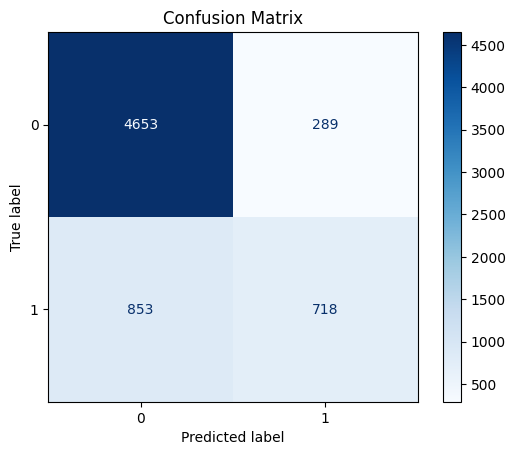

In [32]:
cm = confusion_matrix(y_test, predictions_binary)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()